<a href="https://colab.research.google.com/github/zccarver001-gif/WiDS-University-Datathon-2026/blob/main/WiDS%20University%20Datathon%202026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Files and merge them

In [ ]:
import pandas as pd

df1_filename='evac_zone_status_geo_event_map.csv'
df2_filename='evac_zones_gis_evaczone.csv'
df3_filename='evac_zones_gis_evaczonechangelog.csv'

df1 = pd.read_csv(df1_filename)
df2 = pd.read_csv(df2_filename)
df3 = pd.read_csv(df3_filename)

print('evac_zone_status_geo_event_map.csv:')
print(df1.head())
print('evac_zones_gis_evaczone.csv:')
print(df2.head())
print('evac_zones_gis_evaczonechangelog.csv:')
print(df3.head())

evac_zone_status_geo_event_map.csv:
                 date_created                                    uid_v2  \
0  2023-10-25 11:28:15.254517    sierra-CA_US-SIE-E062-778dddb3cad71e9f   
1  2023-10-25 11:28:15.254550    sierra-CA_US-SIE-E063-f59f54f1edf93b15   
2  2023-10-25 11:28:15.254565    sierra-CA_US-SIE-E060-64dbd0e15d47d9bb   
3  2023-11-02 21:52:49.867450  butte-CA_US-BUT-CNE-311-474a247dbeb74ebf   
4  2024-05-02 20:53:00.964490       kern-CA_US-KRN-289-7cd3f4bbc76a4b2d   

   geo_event_id  
0         14107  
1         14107  
2         14107  
3         14505  
4         18785  
evac_zones_gis_evaczone.csv:
   id                   date_created                  date_modified  \
0   1  2025-04-10 13:22:22.896704+00  2025-08-19 01:58:01.009206+00   
1   2  2025-04-10 13:22:22.896921+00   2025-08-19 01:58:01.00957+00   
2   3  2025-04-10 13:22:22.897002+00  2025-08-19 01:58:01.009741+00   
3   4  2025-04-10 13:22:22.897075+00  2025-08-19 01:58:01.009867+00   
4   5  2025-04-10 13:

In [ ]:
df_merged = pd.merge(df1, df2, on='uid_v2', how='left', suffixes=('_df1', '_df2'))

df_final = pd.merge(df_merged, df3, left_on='id', right_on='evac_zone_id', how='left', suffixes=('', '_df3'))

print('Merged DataFrame (df_final) head:')
print(df_final.head())

print('\nMerged DataFrame info:')
df_final.info()

Merged DataFrame (df_final) head:
             date_created_df1                                    uid_v2  \
0  2023-10-25 11:28:15.254517    sierra-CA_US-SIE-E062-778dddb3cad71e9f   
1  2023-10-25 11:28:15.254550    sierra-CA_US-SIE-E063-f59f54f1edf93b15   
2  2023-10-25 11:28:15.254565    sierra-CA_US-SIE-E060-64dbd0e15d47d9bb   
3  2023-11-02 21:52:49.867450  butte-CA_US-BUT-CNE-311-474a247dbeb74ebf   
4  2024-05-02 20:53:00.964490       kern-CA_US-KRN-289-7cd3f4bbc76a4b2d   

   geo_event_id       id               date_created_df2  \
0         14107  21409.0  2025-04-10 13:24:45.767299+00   
1         14107  21411.0  2025-04-10 13:24:45.767457+00   
2         14107  21406.0  2025-04-10 13:24:45.767079+00   
3         14505   1589.0  2025-04-10 13:22:30.395776+00   
4         18785   6937.0  2025-04-10 13:23:17.799462+00   

                   date_modified is_active display_name  region_id  \
0  2025-07-22 21:10:07.067215+00      True     SIE-E062       47.0   
1  2025-07-22 21:10:

# Drop columns and empty rows


In [ ]:
columns_to_drop = ['evac_zone_id', 'dataset_name', 'source_extra_data', 'pending_updates', 'status', 'id_df3','date_created_df2', 'date_created']
# Filter columns_to_drop to only include those actually present in df_final
existing_columns_to_drop = [col for col in columns_to_drop if col in df_final.columns]

df_final = df_final.drop(columns=existing_columns_to_drop)

# Rename the column 'date_created_df1' to 'date_created'
df_final = df_final.rename(columns={'date_created_df1': 'date_created'})

print('Columns after dropping specified columns and renaming:')
print(df_final.columns.tolist())
print('\nDataFrame info after dropping columns:')
df_final.info()



Columns after dropping specified columns and renaming:
['date_created', 'uid_v2', 'geo_event_id', 'id', 'date_modified', 'is_active', 'display_name', 'region_id', 'source_attribution', 'geom', 'geom_label', 'is_pending_review', 'external_status', 'changes']

DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14743 entries, 0 to 14742
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date_created        14743 non-null  object 
 1   uid_v2              14743 non-null  object 
 2   geo_event_id        14743 non-null  int64  
 3   id                  13972 non-null  float64
 4   date_modified       13972 non-null  object 
 5   is_active           13972 non-null  object 
 6   display_name        13966 non-null  object 
 7   region_id           13972 non-null  float64
 8   source_attribution  13972 non-null  object 
 9   geom                13972 non-null  object 
 10  

In [ ]:
# Convert date columns to datetime objects
df_final['date_modified'] = pd.to_datetime(df_final['date_modified'], errors='coerce')

print('DataFrame info after converting date columns:')
df_final.info()

columns_to_dropna = ['date_modified', 'is_active', 'source_attribution', 'geom', 'geom_label', 'is_pending_review', 'display_name', 'changes']
df_final.dropna(subset=columns_to_dropna, inplace=True)

print('\nDataFrame info after dropping rows with missing values in specified columns:')
df_final.info()

DataFrame info after converting date columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14743 entries, 0 to 14742
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   date_created        14743 non-null  object             
 1   uid_v2              14743 non-null  object             
 2   geo_event_id        14743 non-null  int64              
 3   id                  13972 non-null  float64            
 4   date_modified       13972 non-null  datetime64[ns, UTC]
 5   is_active           13972 non-null  object             
 6   display_name        13966 non-null  object             
 7   region_id           13972 non-null  float64            
 8   source_attribution  13972 non-null  object             
 9   geom                13972 non-null  object             
 10  geom_label          13972 non-null  object             
 11  is_pending_review   13972 non-null  object     

# Define the y

In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

if 'df_final' not in globals():
    print("Error: 'df_final' is not defined. Please run all cells above to merge and clean the data first.")
else:
    def extract_change_count(x):
        try:
            if isinstance(x, str):
                return len(json.loads(x.replace("'", "\"")))
            return 0
        except:
            return 0

    # 1. Feature Engineering: combine current status and activity
    df_final['external_status'] = df_final['external_status'].fillna('Unknown')
    df_final['change_activity_count'] = df_final['changes'].apply(extract_change_count)

    # 2. Define the 'Playbook Situation' signature
    def define_situation(row):
        status = str(row['external_status'])
        active = "Active" if row['is_active'] else "Inactive"
        review = "Pending" if row['is_pending_review'] else "Verified"
        return f"{status} | {active} | {review}"

    df_final['situation_signature'] = df_final.apply(define_situation, axis=1)

    # 3. Map signatures to standardized IDs
    le = LabelEncoder()
    df_final['target_message_id'] = le.fit_transform(df_final['situation_signature'])

    # 4. Prepare Features for Model
    features = ['region_id', 'change_activity_count', 'is_active', 'is_pending_review']
    X = pd.get_dummies(df_final[features], drop_first=True)
    y = df_final['target_message_id']

    print(f"Success: Modeled {len(le.classes_)} unique emergency signatures.")
    display(X.head())

Success: Modeled 35 unique emergency signatures.


,region_id,change_activity_count,is_active_True
0,47.0,1,True
1,47.0,1,True
2,47.0,1,True
3,8.0,1,True
4,19.0,1,True


# Try different models and compare them

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier # StackingClassifier also needs to be imported
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using the X and y defined in the previous cell
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Check if X_train is available and not empty before defining models
if 'X_train' in globals() and X_train.shape[0] > 0:
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': GaussianNB(),
        'Gradient Boost': GradientBoostingClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'MLP': MLPClassifier(random_state=42),
        'Bagging': BaggingClassifier(random_state=42),
        'Voting': VotingClassifier( estimators=[ ('rf', RandomForestClassifier(n_estimators=100, random_state=42))], voting='hard'),
        'Stacking': StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)), ('lr', LogisticRegression(random_state=42))], final_estimator=LogisticRegression(random_state=42))
    }

    print("--- Training and Evaluating Models ---")
    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy_val = accuracy_score(y_test, predictions)
        f1_score_val = f1_score(y_test, predictions, average='weighted')
        precision_val = precision_score(y_test, predictions, average='weighted')
        recall_val = recall_score(y_test, predictions, average='weighted')
        print(f"{name} Accuracy: {accuracy_val:.4f}")
        print(f"{name} F1 Score: {f1_score_val:.4f}")
        print(f"{name} Precision: {precision_val:.4f}")
        print(f"{name} Recall: {recall_val:.4f}")

    # Evaluate models based on accuracy_score to find the best model
    best_model_name = ''
    best_accuracy = -1
    for name, model in models.items():
        accuracy = accuracy_score(y_test, model.predict(X_test))
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_name = name
    print(f"\nBest Model (based on accuracy): {best_model_name} with Accuracy: {best_accuracy:.4f}")
else:
    print("X_train is not defined or is empty, skipping model training and evaluation.")

X_train shape: (1395, 3)
y_train shape: (1395,)
X_test shape: (12560, 3)
y_test shape: (12560,)
--- Training and Evaluating Models ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Accuracy: 0.9262
Random Forest F1 Score: 0.9059
Random Forest Precision: 0.8899
Random Forest Recall: 0.9262


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Accuracy: 0.7112
Logistic Regression F1 Score: 0.6568
Logistic Regression Precision: 0.6415
Logistic Regression Recall: 0.7112


...

MLP Accuracy: 0.7923
MLP F1 Score: 0.7202
MLP Precision: 0.6610
MLP Recall: 0.7923
Bagging Accuracy: 0.9279
Bagging F1 Score: 0.9074
Bagging Precision: 0.8911
Bagging Recall: 0.9279


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Voting Accuracy: 0.9262
Voting F1 Score: 0.9059
Voting Precision: 0.8899
Voting Recall: 0.9262


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (26) does not match total number of classes (27). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in pro

Stacking Accuracy: 0.9284
Stacking F1 Score: 0.9032
Stacking Precision: 0.8817
Stacking Recall: 0.9284

Best Model (based on accuracy): Gradient Boost with Accuracy: 0.9306


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
import numpy as np # Add numpy import for np.unique and np.concatenate
from sklearn.ensemble import GradientBoostingClassifier # Explicitly import GradientBoostingClassifier

# Ensure le (LabelEncoder) is available, assuming it's from previous cells
# If le is not defined, you might need to re-run or explicitly import/define it here
# For now, assuming le is globally available from cell 1pn1DMwwi1VX

if 'X_train' in globals() and 'y_train' in globals():
    # Define the parameter grid for GradientBoost
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 20, 50],
        'min_samples_leaf': [1, 2, 4]
    }

    # Initialize GradientBoost
    rf_clf = GradientBoostingClassifier(random_state=42)

    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

    # Fit GridSearchCV
    print("\n--- Performing Grid Search for Random Forest ---")
    grid_search.fit(X_train, y_train)

    print(f"Best parameters found: {grid_search.best_params_}")
    print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

    # Get the best model from Grid Search
    best_rf_model = grid_search.best_estimator_


    y_tuned = best_rf_model.predict(X_train)
    accuracy_tu = accuracy_score(y_train, y_tuned)
    f1_tu = f1_score(y_train, y_tuned, average='weighted')
    precision_tu = precision_score(y_train, y_tuned, average='weighted')
    recall_tu = recall_score(y_train, y_tuned, average='weighted')

    print("\n--- Tuned Random Forest Model Performance on Training Set ---")
    print(f"Accuracy: {accuracy_tu:.4f}")
    print(f"F1 Score: {f1_tu:.4f}")
    print(f"Precision: {precision_tu:.4f}")
    print(f"Recall: {recall_tu:.4f}")

else:
    print("Error: X_train or y_train not found. Please ensure feature engineering and data splitting cells are run.")


--- Performing Grid Search for Random Forest ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.9290

--- Tuned Random Forest Model Performance on Training Set ---
Accuracy: 0.9341
F1 Score: 0.9149
Precision: 0.9048
Recall: 0.9341


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Evaluate the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted')
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted')

print("\n--- Tuned Random Forest Model Performance on Test Set ---")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"F1 Score: {f1_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print("\nClassification Report for Tuned Random Forest:")
unique_labels = np.unique(np.concatenate([y_test, y_pred_tuned]))
target_names = [le.classes_[i] for i in unique_labels]
print(classification_report(y_test, y_pred_tuned, labels=unique_labels, target_names=target_names, zero_division=0))


--- Tuned Random Forest Model Performance on Test Set ---
Accuracy: 0.9289
F1 Score: 0.9079
Precision: 0.8933
Recall: 0.9289

Classification Report for Tuned Random Forest:
                                                    precision    recall  f1-score   support

                             0 | Active | Verified       0.00      0.00      0.00         6
                            00 | Active | Verified       1.00      1.00      1.00        71
                           1 | Inactive | Verified       0.00      0.00      0.00        32
                           2 | Inactive | Verified       0.00      0.00      0.00        67
                           3 | Inactive | Verified       0.00      0.00      0.00        31
  Evacuation Level 1: Be Ready | Active | Verified       0.24      0.04      0.07        99
Evacuation Level 1: Be Ready | Inactive | Verified       0.00      0.00      0.00        27
    Evacuation Level 2: Be Set | Active | Verified       0.71      0.88      0.79        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Operational Prototype: Early Warning & Playbook Engine
This section translates our model predictions into tangible operational actions and standardized communication.

In [ ]:
import json
import pandas as pd

def get_playbook_recommendation(signature):
    sig = str(signature).lower()
    if 'evacuation order' in sig:
        return "IMMEDIATE ACTION: Activate sirens, broadcast EAS, and deploy SAR for door-to-door notifications."
    elif 'evacuation warning' in sig:
        return "PREPARATORY ACTION: Notify transit for vulnerable residents, stage resources at zone boundaries."
    elif 'advisory' in sig or 'normal' in sig:
        return "MONITORING: Refresh situational awareness every 15 mins; update NGO partner status."
    else:
        return "CAUTION: Unknown status. Verify with field incident command immediately."

def generate_alert_message(row):
    zone = row['display_name']
    status = str(row['external_status'])
    msg = f"[EMERGENCY ALERT] Zone {zone} status updated to: {status.upper()}. "
    if 'Order' in status:
        msg += "Leave now. Take essentials. Do not wait. Route instructions to follow."
    elif 'Warning' in status:
        msg += "Prepare to leave. Gather pets and documents. Monitor local media."
    else:
        msg += "Stay alert. Check maps for updates."
    return msg

# Ensure df_final is ready
if 'df_final' in globals():
    high_risk_df = df_final.nlargest(1000, 'change_activity_count').copy()
    high_risk_df['Recommended_Next_Action'] = high_risk_df['situation_signature'].apply(get_playbook_recommendation)
    high_risk_df['Standardized_Message'] = high_risk_df.apply(generate_alert_message, axis=1)
    print("--- Prototype Dashboard: Trigger Recommendations ---")
    display(high_risk_df[['display_name', 'external_status', 'Recommended_Next_Action', 'Standardized_Message']])

--- Prototype Dashboard: Trigger Recommendations ---


,display_name,external_status,Recommended_Next_Action,Standardized_Message
707,SIS-1233,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone SIS-1233 status updated...
3733,YUB-E089,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone YUB-E089 status updated...
5023,CAS-VALVERDE,Normal,MONITORING: Refresh situational awareness ever...,[EMERGENCY ALERT] Zone CAS-VALVERDE status upd...
6870,P18,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone P18 status updated to: ...
7118,CR02M,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone CR02M status updated to...
...,...,...,...,...
10961,RVC-2121,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone RVC-2121 status updated...
10982,RVC-2122-A,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone RVC-2122-A status updat...
10983,RVC-2122-A,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone RVC-2122-A status updat...
10986,RVC-2122-A,Unknown,CAUTION: Unknown status. Verify with field inc...,[EMERGENCY ALERT] Zone RVC-2122-A status updat...


### NGO Outreach Prioritization
We can prioritize communities at risk by identifying zones with the highest frequency of state changes, suggesting 'volatile' situations where residents might be confused or fatigued.

In [ ]:
if 'df_final' in globals():
    priority_outreach = df_final.groupby('region_id').agg({
        'change_activity_count': 'sum',
        'uid_v2': 'count'
    }).rename(columns={'uid_v2': 'zone_count'})
    priority_outreach['priority_score'] = (priority_outreach['change_activity_count'] * 0.7) + (priority_outreach['zone_count'] * 0.3)
    priority_outreach = priority_outreach.sort_values(by='priority_score', ascending=False)
    print("--- Top Regions for Prioritized NGO/Agency Outreach ---")
    display(priority_outreach.head(10))

--- Top Regions for Prioritized NGO/Agency Outreach ---


,change_activity_count,zone_count,priority_score
region_id,,,
34.0,2307,1768,2145.3
22.0,1422,1284,1380.6
48.0,1239,1154,1213.5
1996.0,984,978,982.2
2924.0,969,683,883.2
41.0,815,672,772.1
2038.0,612,580,602.4
38.0,598,598,598.0
46.0,433,433,433.0


In [ ]:
!pip install shap

### Model Interpretability with SHAP
SHAP values help us understand how each feature contributes to the model's prediction for a specific class. Below, we visualize the global importance of our features.

ExactExplainer explainer: 201it [00:15,  6.92it/s]                         


SHAP Feature Importance: Understanding Model Drivers


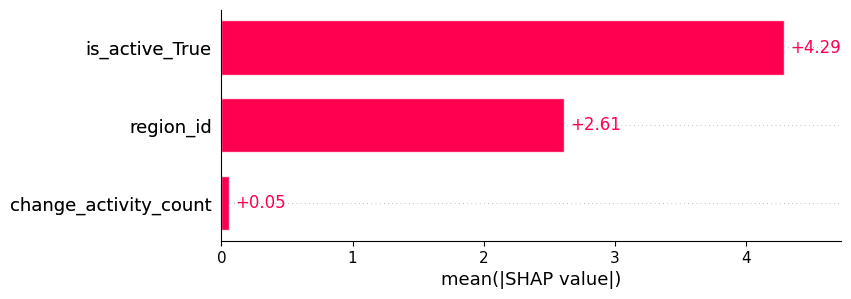

In [ ]:
import shap
import numpy as np

if 'best_rf_model' in globals():
    # Convert X_subset to float to avoid boolean type errors with SHAP/NumPy
    # SHAP's masker can fail on is_finite checks for bools
    X_subset = X_test[:200].astype(float)

    # Use the predict method and provide the numeric background dataset
    explainer = shap.Explainer(best_rf_model.predict, X_subset)
    shap_values = explainer(X_subset)

    print("SHAP Feature Importance: Understanding Model Drivers")

    # Visualize global importance
    shap.plots.bar(shap_values)
else:
    print("Error: 'best_rf_model' not found. Please ensure model training cells are run.")